# Diagnostico de politicas visuales

Diagnostico completo de `policy_moderate_v2`, ejemplos visuales y preparacion de evaluacion VSR barata.

In [1]:
from IPython.display import Image, Markdown, display

from data_cleaning.src.visual_quality_notebook_utils import (
    analizar_wer_cer,
    candidatos_falsos_positivos,
    cargar_tablas_auditoria,
    comando_inferencia_existente,
    composicion_muestra_vsr,
    conclusion_presentacion,
    formato_predicciones_futuras,
    generar_sheets_diagnostico,
    resumen_ejecutivo,
    resumen_muestra_vsr,
    retencion_por_grupo,
    tabla_excluidos,
    tabla_retenciones,
    top_reasons,
)

tablas = cargar_tablas_auditoria()
ROOT = tablas["root"]
sanity = tablas["sanity"]
policy = tablas["policy"]
policy_v1 = tablas["policy_v1"]
sample = tablas["sample"]
preview_dir = ROOT / "data_cleaning" / "outputs" / "visual_quality_audit" / "diagnostico_politicas"

## Resumen ejecutivo

In [2]:
display(resumen_ejecutivo(sanity, policy, policy_v1))
display(tabla_retenciones(policy, policy_v1))

,metric,value
0,clips,5950
1,input_kind,{'roi_npz': 5950}
2,run_mode,{'roi_audit': 5950}
3,roi_coverage,100.00%
4,decision_sanity,"{'keep': 3343, 'review': 2607}"
5,review_severity_v2,"{'none': 3331, 'medium': 1082, 'high': 810, 'l..."
6,training_usability,"{'usable': 3330, 'questionable': 2402, 'bad_ca..."
7,policy_conservative_v2,"{'policy': 'policy_conservative', 'keep': 5950..."
8,policy_moderate_v2,"{'policy': 'policy_moderate', 'keep': 5732, 'e..."
9,policy_strict_v2,"{'policy': 'policy_strict', 'keep': 3830, 'exc..."


,version,policy,keep,exclude,retention_pct
0,v2,policy_conservative,5950,0,100.00
1,v2,policy_moderate,5732,218,96.34
2,v2,policy_strict,3830,2120,64.37
3,v1,policy_moderate,5140,810,86.39


## Excluidos por policy_moderate_v2

In [3]:
display(tabla_excluidos(policy, n=25))
display(top_reasons(policy.loc[policy.policy_moderate == "exclude"], "policy_moderate_exclusion_reasons", top=20))
display(top_reasons(policy, "training_usability_reasons", top=20))

,source_id,clip,policy_moderate,training_usability,training_usability_reasons,policy_moderate_exclusion_reasons,quality_score,review_score,review_reasons
3399,Las y los estudiantes al frente - Entrevista a la,clip_0224,exclude,bad_candidate,mouth_occluded_many_frames;roi_unstable_or_bad...,training_usability:mouth_occluded_many_frames;...,0.4937,14.0,blur_extremo;boca_tapada_o_poco_visible;baja_t...
828,ANÉCDOTA VIAJE MUNDIAL BRASIL 2014 parte 1,clip_0187,exclude,bad_candidate,mouth_visible;blur_low_texture;scene_discontin...,training_usability:blur_low_texture;training_u...,0.5059,13.0,blur_extremo;baja_textura_boca;contraste_bajo;...
4374,PROFESIONES ARGENTINAS 🚖 Los SECRETOS de los T...,clip_0026,exclude,bad_candidate,mouth_visible;blur_low_texture;scene_discontin...,training_usability:blur_low_texture;training_u...,0.5196,13.0,blur_extremo;baja_textura_boca;contraste_bajo;...
914,ANÉCDOTA VIAJE MUNDIAL BRASIL 2014 parte 1,clip_0281,exclude,bad_candidate,mouth_visible;blur_low_texture;scene_discontin...,training_usability:blur_low_texture;training_u...,0.5525,13.0,blur_extremo;baja_textura_boca;contraste_bajo;...
707,ANÉCDOTA VIAJE MUNDIAL BRASIL 2014 parte 1,clip_0050,exclude,bad_candidate,mouth_visible;blur_low_texture;scene_discontin...,training_usability:blur_low_texture;training_u...,0.5570,13.0,blur_extremo;baja_textura_boca;contraste_bajo;...
4279,PROFESIONES ARGENTINAS GUARDAESPALDAS - Telefe...,clip_0080,exclude,bad_candidate,mouth_visible;blur_low_texture;scene_discontin...,training_usability:blur_low_texture;training_u...,0.5765,13.0,blur_extremo;baja_textura_boca;contraste_bajo;...
4196,PROFESIONES ARGENTINAS GOMEROS - Telefe Noticias,clip_0052,exclude,bad_candidate,mouth_visible;blur_low_texture;scene_discontin...,training_usability:blur_low_texture;training_u...,0.5869,13.0,blur_extremo;baja_textura_boca;contraste_bajo;...
837,ANÉCDOTA VIAJE MUNDIAL BRASIL 2014 parte 1,clip_0196,exclude,bad_candidate,mouth_visible;blur_low_texture;scene_discontin...,training_usability:blur_low_texture;training_u...,0.6077,13.0,blur_extremo;baja_textura_boca;contraste_bajo;...
4194,PROFESIONES ARGENTINAS GOMEROS - Telefe Noticias,clip_0049,exclude,bad_candidate,mouth_visible;blur_low_texture;scene_discontin...,training_usability:blur_low_texture;training_u...,0.6155,13.0,blur_extremo;baja_textura_boca;contraste_bajo;...
4177,PROFESIONES ARGENTINAS GOMEROS - Telefe Noticias,clip_0031,exclude,bad_candidate,mouth_visible;blur_low_texture;scene_discontin...,training_usability:blur_low_texture;training_u...,0.6240,13.0,blur_extremo;baja_textura_boca;contraste_bajo;...


,reason,clips
0,training_usability:blur_low_texture,217
1,training_usability:scene_discontinuity,168
2,training_usability:quality_tail,161
3,training_usability:low_mouth_motion,52
4,training_usability:mouth_occluded_many_frames,1
5,training_usability:roi_unstable_or_bad_crop,1
6,training_usability:side_profile_or_partial_mouth,1


,reason,clips
0,mouth_visible,5940
1,blur_low_texture,1917
2,scene_discontinuity,1213
3,quality_tail,595
4,low_mouth_motion,54
5,mouth_occluded_many_frames,1
6,roi_unstable_or_bad_crop,1
7,side_profile_or_partial_mouth,1


## Retencion por fuente y split

In [4]:
display(retencion_por_grupo(policy, "source_id").sort_values("retention_pct").head(40))
display(retencion_por_grupo(policy, "split"))

policy_moderate,source_id,total,keep,exclude,retention_pct
19,PROFESIONES ARGENTINAS GOMEROS - Telefe Noticias,55,39,16,70.91
18,PROFESIONES ARGENTINAS GINECÓLOGOS - Telefe No...,68,53,15,77.94
22,PROFESIONES ARGENTINAS 🚖 Los SECRETOS de los T...,73,57,16,78.08
11,Las y los estudiantes al frente - Entrevista a la,257,207,50,80.54
21,PROFESIONES ARGENTINAS KINESIÓLOGOS - Telefe N...,62,50,12,80.65
0,ANÉCDOTA VIAJE MUNDIAL BRASIL 2014 parte 1,302,250,52,82.78
28,Profesiones argentinas GASTROENTERÓLOGOS #Tele...,75,66,9,88.00
9,LA CHABONA X RAMI BILBAO DIVAS DIARY ABITARE...,26,23,3,88.46
16,PROFESIONES ARGENTINAS DIRECTORES de CASTING -...,87,77,10,88.51
20,PROFESIONES ARGENTINAS GUARDAESPALDAS - Telefe...,83,75,8,90.36


policy_moderate,split,total,keep,exclude,retention_pct
0,test,658,658,0,100.00
1,train,4826,4623,203,95.79
2,val,466,451,15,96.78


## Posibles falsos positivos

In [5]:
display(candidatos_falsos_positivos(policy, n=20))

,source_id,clip,training_usability_reasons,quality_score,mouth_activity_score,mouth_visibility_score,scene_cut_score,blur_score
5124,Profesiones argentinas GASTROENTERÓLOGOS #Tele...,clip_0024,mouth_visible;blur_low_texture;scene_discontin...,0.7744,1.0000,0.9552,1.0000,0.0381
4326,PROFESIONES ARGENTINAS KINESIÓLOGOS - Telefe N...,clip_0042,mouth_visible;blur_low_texture;scene_discontin...,0.7456,1.0000,0.8393,1.0000,0.0320
4414,PROFESIONES ARGENTINAS 🚖 Los SECRETOS de los T...,clip_0074,mouth_visible;blur_low_texture;scene_discontin...,0.7456,1.0000,0.9231,1.0000,0.0139
4938,Profesiones Argentinas EMPLEADOS de PANADERÍAS...,clip_0060,mouth_visible;blur_low_texture;scene_discontin...,0.7454,1.0000,0.9128,1.0000,0.0390
4420,PROFESIONES ARGENTINAS 🚖 Los SECRETOS de los T...,clip_0080,mouth_visible;blur_low_texture;scene_discontin...,0.7438,0.8860,0.9554,1.0000,0.0218
4070,PROFESIONES ARGENTINAS DIRECTORES de CASTING -...,clip_0097,mouth_visible;blur_low_texture;scene_discontin...,0.7366,1.0000,0.8638,1.0000,0.0000
3397,Las y los estudiantes al frente - Entrevista a la,clip_0222,mouth_visible;blur_low_texture;scene_discontin...,0.7349,1.0000,0.7920,1.0000,0.0365
4011,PROFESIONES ARGENTINAS DIRECTORES de CASTING -...,clip_0032,mouth_visible;blur_low_texture;scene_discontin...,0.7302,1.0000,0.8343,1.0000,0.0286
4314,PROFESIONES ARGENTINAS KINESIÓLOGOS - Telefe N...,clip_0028,mouth_visible;blur_low_texture;scene_discontin...,0.7285,1.0000,0.8206,1.0000,0.0000
3382,Las y los estudiantes al frente - Entrevista a la,clip_0207,mouth_visible;blur_low_texture;scene_discontin...,0.7271,1.0000,0.7185,1.0000,0.0000


## WER/CER disponible

In [6]:
wer = analizar_wer_cer(policy)
display(wer["resumen"])
for name, table in wer["grupos"].items():
    display(Markdown(f"**{name}**"))
    display(table)

,candidate,matched,policy_moderate_counts,comparable,warning
0,"{'tipo': 'inf_ref_hyp_con_mapeo', 'path': 'vsr...",148,{'keep': 148},False,WER actual no valida policy_moderate porque lo...


**por_decision**

,decision,clips,wer_promedio,cer_promedio
0,keep,142,0.7720,0.4628
1,review,6,0.7324,0.4550


**por_review_severity**

,review_severity,clips,wer_promedio,cer_promedio
0,medium,6,0.7324,0.4550
1,none,142,0.7720,0.4628


...

,policy_moderate,clips,wer_promedio,cer_promedio
0,keep,148,0.7704,0.4624


**por_policy_strict**

,policy_strict,clips,wer_promedio,cer_promedio
0,exclude,6,0.7324,0.4550
1,keep,142,0.7720,0.4628


**por_review_reason_group**

,review_reason_group,clips,wer_promedio,cer_promedio
0,none,142,0.7720,0.4628
1,scene_cut,6,0.7324,0.4550


## Muestra estratificada para evaluacion VSR

In [7]:
display(resumen_muestra_vsr(sample))
display(composicion_muestra_vsr(sample))
display(formato_predicciones_futuras())
display(comando_inferencia_existente())

,metric,value
0,clips,300
1,policy_moderate_v2,"{'keep': 200, 'exclude': 100}"
2,training_usability,"{'bad_candidate': 100, 'questionable': 100, 'u..."
3,split,"{'train': 258, 'val': 30, 'test': 12}"
4,fuentes,31


,policy_moderate_v2,training_usability,split,clips
0,exclude,bad_candidate,train,92
1,exclude,bad_candidate,val,8
2,keep,questionable,test,6
3,keep,questionable,train,83
4,keep,questionable,val,11
5,keep,usable,test,6
6,keep,usable,train,83
7,keep,usable,val,11


,columna,descripcion
0,source_id,fuente/titulo del manifest
1,clip,clip_NNNN original
2,split,split de la muestra
3,reference,texto esperado
4,hypothesis,salida VSR
5,wer,"WER por clip, fraccion 0-1"
6,cer,"CER por clip, fraccion 0-1"


,estado,detalle
0,comando existente,vsr_main.py evalua un scenario exportado al la...
1,inferencia,python vsr_main.py --database Rioplatense --sc...
2,cruce esperado,convertir inference/test.inf + mapeo.csv a CSV...


## Ejemplos visuales

**excluidos por training_usability:blur_low_texture**

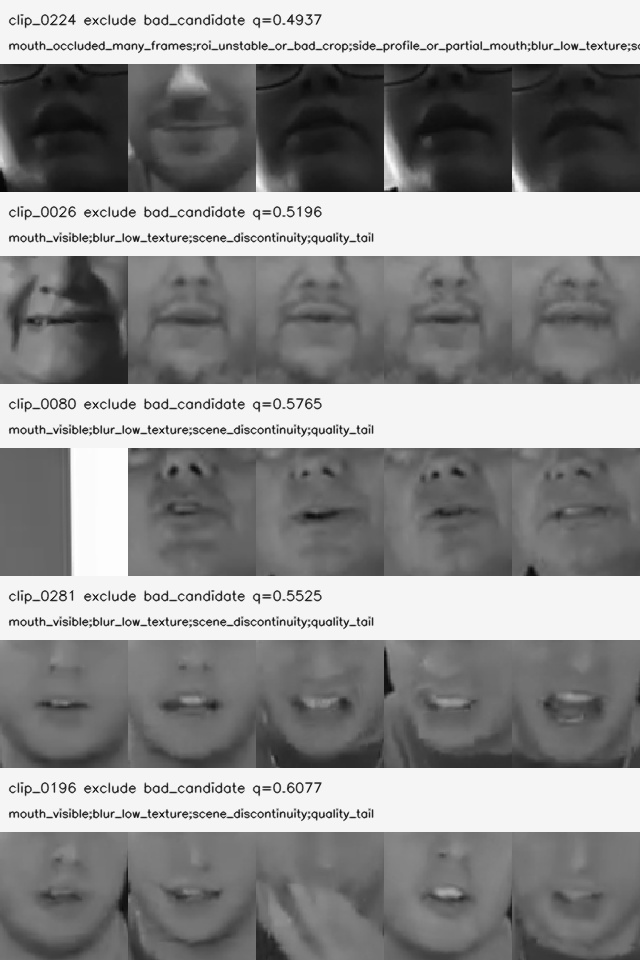

**excluidos por training_usability:scene_discontinuity**

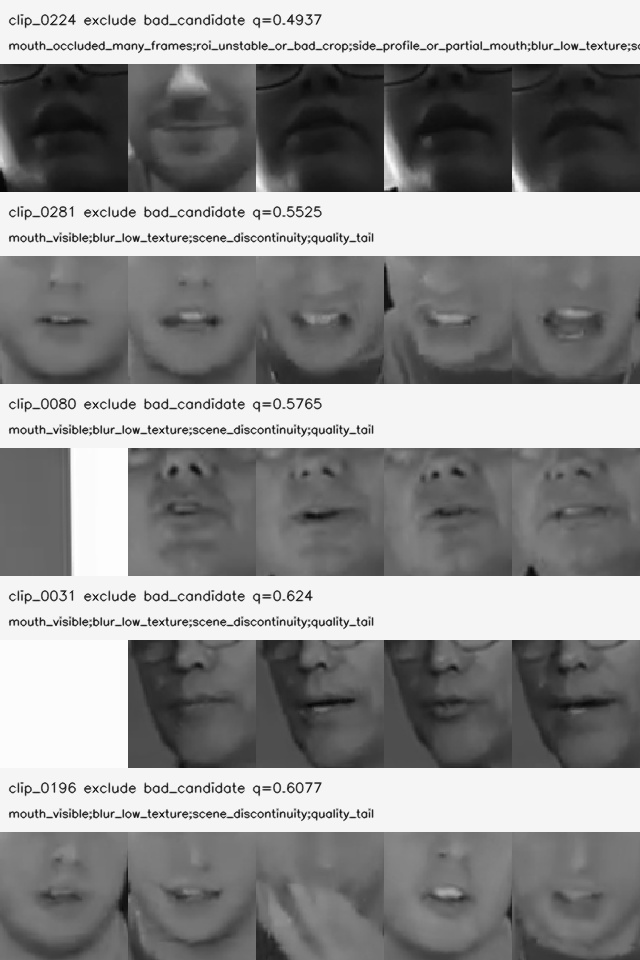

**excluidos por training_usability:quality_tail**

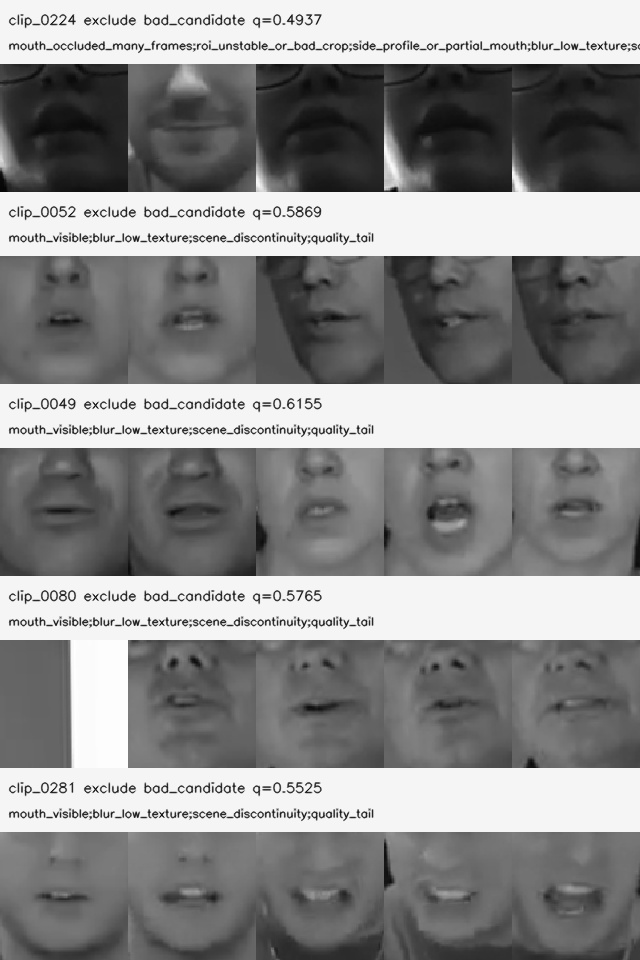

**excluidos por training_usability:low_mouth_motion**

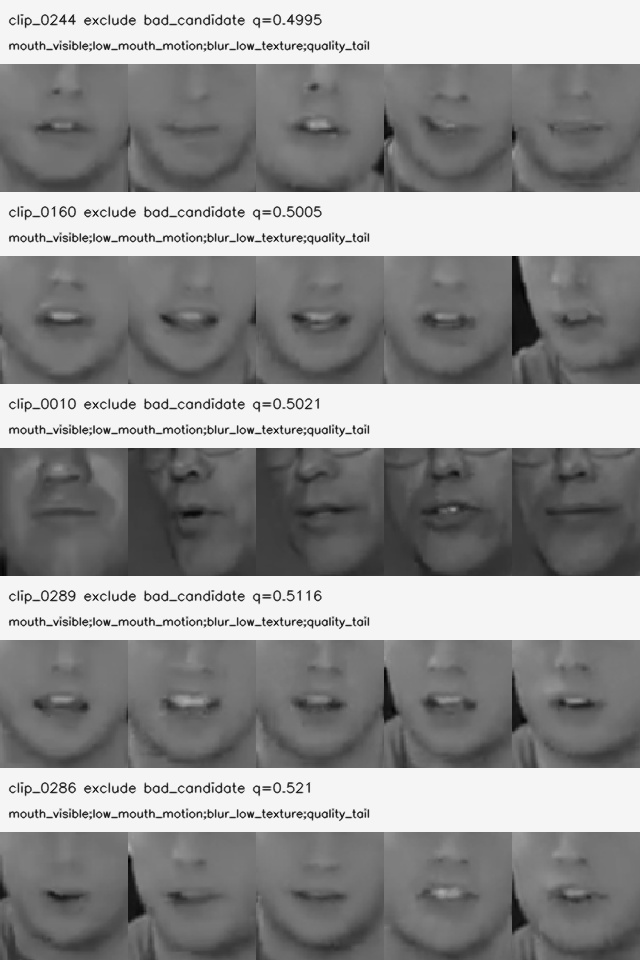

**excluidos por training_usability:mouth_occluded_many_frames**

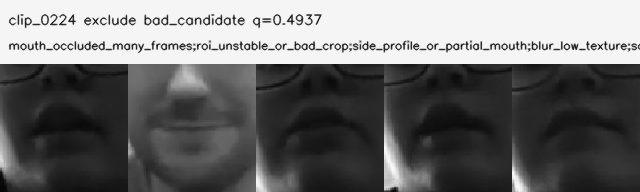

**posibles falsos positivos**

Sin ejemplos renderizables.

**fronterizos conservados**

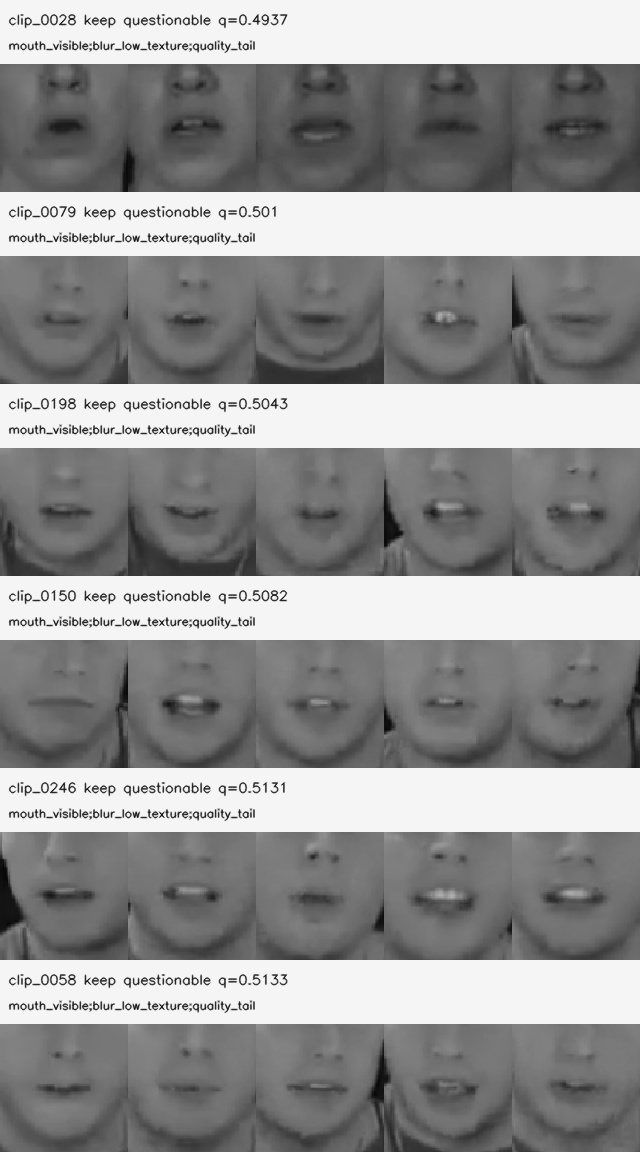

In [8]:
sheets = generar_sheets_diagnostico(policy, preview_dir)
for title, image in sheets.items():
    display(Markdown(f"**{title}**"))
    if image:
        display(Image(filename=str(image)))
    else:
        display(Markdown("Sin ejemplos renderizables."))

## Conclusion operativa

In [9]:
display(Markdown(conclusion_presentacion(policy, wer["impact"], sample)))

No entrenar todavia con un filtro visual final: falta medir impacto VSR barato por grupo.  
policy_moderate_v2 retiene 96.34% (5732 clips) y excluye 218 bad_candidate.  
policy_strict_v2 retiene 64.37% y queda solo como analisis de sensibilidad.  
WER/CER actual no valida excludes: la muestra estratificada es el siguiente insumo.  
Muestra VSR disponible: 300 clips en data/metadata/visual_quality_vsr_eval_sample.csv.